In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import sqlite3

In [119]:
conn = sqlite3.connect("customer_churn.db")

sql_query = """
    select name 
    from sqlite_master
    where type = 'table'
"""

tables = pd.read_sql(sql_query, conn)

for table_names in tables['name']:
    df = pd.read_sql(f"select * from {table_names}", conn)
    globals()[f"df_{table_names}"] =df
    print(f"Creted dataframe: df_{table_names}")

    columns_query = f"PRAGMA table_info({table_names});"
    columns = pd.read_sql(columns_query, conn)
    print(columns['name'].tolist())

conn.close()

Creted dataframe: df_db_customer
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']
Creted dataframe: df_db_subscription
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']
Creted dataframe: df_db_support
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [120]:
df_db_coustomer = df_db_customer.drop(columns = ['interests', 'pincode',], inplace=True)

In [121]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [122]:
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [123]:
df_db_customer['name'] = df_db_customer['name'].str.title()
df_db_customer.head(5)

,customerid,name,country,state,gender,dob
0,0002-ORFBO,Keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,Raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,Lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,Mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,Mira,India,Delhi,Female,1990-05-05


In [124]:
state_country_mapping = df_db_customer.dropna(subset = ['country']).set_index('state')['country'].to_dict()
state_country_mapping

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Uttar Pradesh': 'India',
 'Telangana': 'India'}

In [125]:
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [126]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,name,country,state,gender,dob


In [127]:
print(df_db_customer.to_string())

    customerid        name country          state  gender        dob
0   0002-ORFBO      Keshav   India    Maharashtra    Male 1982-04-12
1   0003-MKNFE      Raghav   India      Karnataka    Male 1995-11-23
2   0004-TLHLJ      Lalita   India          Delhi  Female 1978-02-15
3   0011-IGKFF       Mohan   India       Nagaland    Male 2001-08-30
4   0013-EXCHZ        Mira   India          Delhi  Female 1990-05-05
5   0013-MHZWF       Durga   India          Delhi  Female 1988-12-10
6   0013-SMEOE        Mina   India      Meghalaya  Female 1976-09-21
7   0014-BMAQU       Madan   India      Rajasthan    Male 1999-03-14
8   0015-UOCOJ        Maya   Nepal      Kathmandu  Female 1985-07-07
9   0016-QLJIS       Arjun   Nepal      Kathmandu    Male 1993-10-29
10  0017-DINOC       Shiva   India    Maharashtra    Male 1997-01-22
11  0017-IUDMW   Rangadevi   India      Karnataka  Female 1981-06-18
12  0018-NYROU      Chitra   India      Telangana  Female 2004-12-01
13  0019-EFAEP        Raju   India

In [128]:
date_type = ['cancellation_date','renewal_date', 'subscription_start_date']
df_db_subscription[date_type] = df_db_subscription[date_type].apply(pd.to_datetime)

In [129]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [130]:
df_db_support.drop(columns = ['col_1','comment'], inplace=True)

In [131]:
df_db_support['complaint_date'] = df_db_support['complaint_date'].apply(pd.to_datetime)

In [132]:
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,41,0


In [133]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   customerid  21 non-null     str           
 1   name        21 non-null     str           
 2   country     21 non-null     str           
 3   state       21 non-null     str           
 4   gender      21 non-null     str           
 5   dob         21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [134]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
 11  churn_flag               21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(3), str(5

In [135]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [139]:
df = (df_db_subscription
    .merge(df_db_customer, on='customerid', how= 'left') 
    .merge(df_db_support, on='customerid', how= 'left'))

In [140]:
df.shape

(21, 21)

In [141]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,Keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,Raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,Lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,Mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,Mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [107]:
df_db_customer['customerid'].nunique()


21

In [108]:
df_db_subscription['customerid'].nunique()



21

In [109]:
df_db_support['customerid'].nunique()

7

In [136]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [137]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1


In [138]:
df_db_support = df_db_support.sort_values('complaint_count').drop_duplicates('customerid', keep = 'last')

In [155]:
#print(df.to_string())

In [142]:
df.to_csv("exported_churn_data.csv", index = False)

In [143]:
# churn rate

churn_rate = round(df['churn_flag'].mean()*100,2)
print(churn_rate," %")

28.57  %


In [144]:
#retenion rate

retenion_rate = 100 - churn_rate
print(retenion_rate, " %")

71.43  %


In [145]:
#churn by plan type

churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'percent'))
print(churn_by_plan, end = '\n\n')

#churn by state

churn_by_plan = (df.groupby('state')['monthly_charges'].sum().reset_index(name = 'percent'))
print(churn_by_plan.sort_values('percent'), end = '\n\n')

#churn by subscription

churn_by_plan = (df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'percent'))
print(churn_by_plan)

  plan_type  percent
0     Basic    60.00
1   Premium    14.29
2  Standard    22.22

           state  percent
1      Karnataka    20.98
2      Kathmandu    20.98
5       Nagaland    22.99
7      Telangana    30.98
6      Rajasthan    36.98
4      Meghalaya    42.97
3    Maharashtra    50.97
0          Delhi    52.96
8  Uttar Pradesh   115.98

  subscription_type  percent
0           Organic     0.00
1              Paid    16.67
2          Refferal    83.33


In [146]:
# average revenue

avg = df['monthly_charges'].mean()
print(avg.round(2))

18.85


In [147]:
# tenure

today = pd.Timestamp.today()

df['tenure_days'] = np.where(df['cancellation_date'].notna(),
                             (df['cancellation_date'] - df['subscription_start_date']).dt.days,
                             (today - df['subscription_start_date']).dt.days
                            )

avg_tenure = df['tenure_days'].mean()
print(avg_tenure.round(2))


1535.14


In [148]:
#revenue loss

revenue_loss = df.loc[df['churn_flag'] == 1 , 'monthly_charges'].sum()
print(revenue_loss.round(2))

73.94


In [149]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='str')

In [150]:
# escalation rate

escalation_rate =( df['escalations'] == 'Y').mean()
print((escalation_rate*100).round(2))

14.29


In [151]:
# average customer complaint

cus_complaint = df['complaint_count'].sum()/df['customerid'].nunique()
print(round(cus_complaint,2))

0.43


In [153]:
# correlation escaltoin vs churn

df['escalations'] = np.where(df['escalations'] == 'Y' ,1,0)
corr_df = df[['churn_flag','escalations']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])

print(round(correlation,2))





0.65


In [ ]:
#df.drop(columns = ['ecalations'])

In [154]:
cond = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
    
]

state = ['low', 'med', 'high']

df['churn_risk'] = np.select(cond, state, default = 'unknown')

In [155]:
#df.head()

In [156]:
# visualization using matplotlib

In [157]:
df_visual = df.copy()

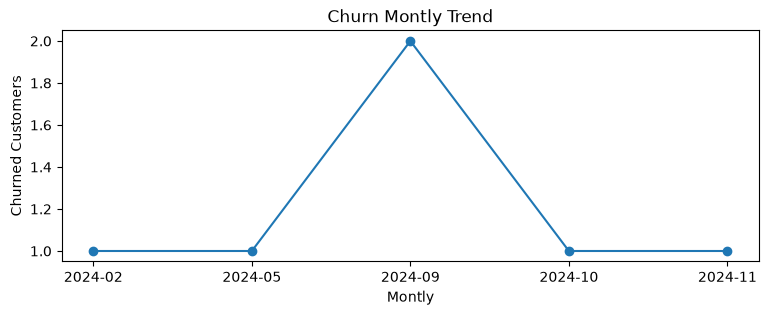

In [158]:
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(9,3))
plt.plot(churn_trend.index.astype('str'), churn_trend.values, marker='o' )

plt.title('Churn Montly Trend')
plt.ylabel('Churned Customers')
plt.xlabel('Montly')
plt.show()


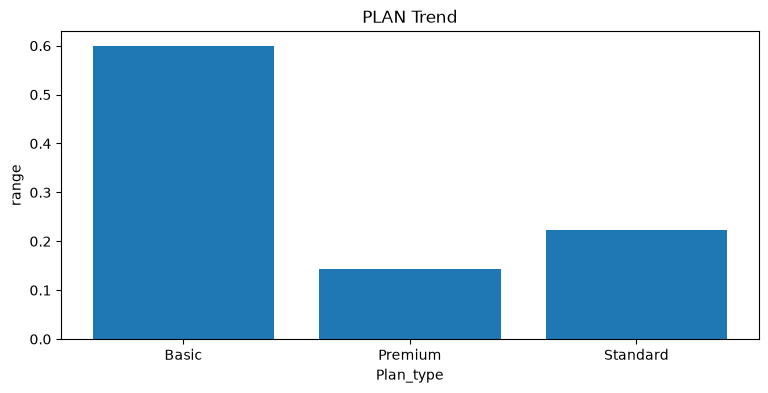

In [159]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize=(9,4))
plt.bar(churn_plan.index, churn_plan.values)
plt.title('PLAN Trend')
plt.ylabel('range')
plt.xlabel('Plan_type')
plt.show()


In [160]:
#visulaization using seaborn

In [161]:
df_encoded = df_visual[[ 'plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]  #incorrect based on priority
cat_col = ['plan_type', 'contract_type', 'churn_risk']
for i in cat_col:
    df_encoded[i] = df_encoded[i].astype('category').cat.codes

In [162]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,0
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

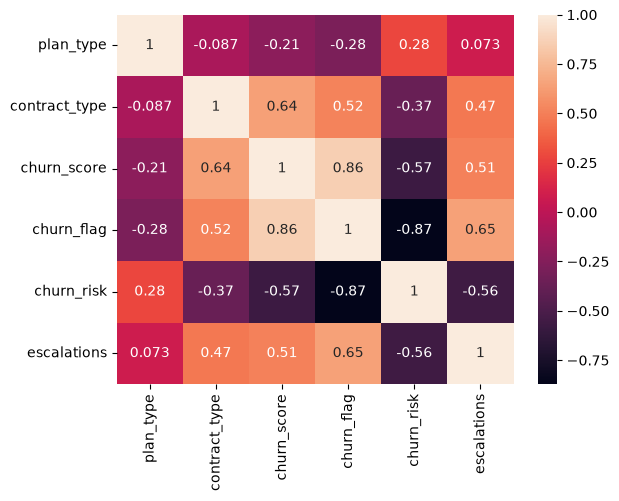

In [163]:
sb.heatmap(df_encoded.corr(), annot=True)

In [164]:
df_encoded = df_visual[[ 'plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]  #incorrect based on priority
order = {'plan_type' : ['Basic', 'Standard', 'Premium'],
         'contract_type' : ['Premium', 'Annual'],
         'churn_risk' : ['low', 'med', 'high']
        }
for i in order:
    df_encoded[i] = df_encoded[i].astype('category').cat.codes

In [165]:
df_visual['contract_type'].unique()

<StringArray>
['Annual', 'Monthly']
Length: 2, dtype: str

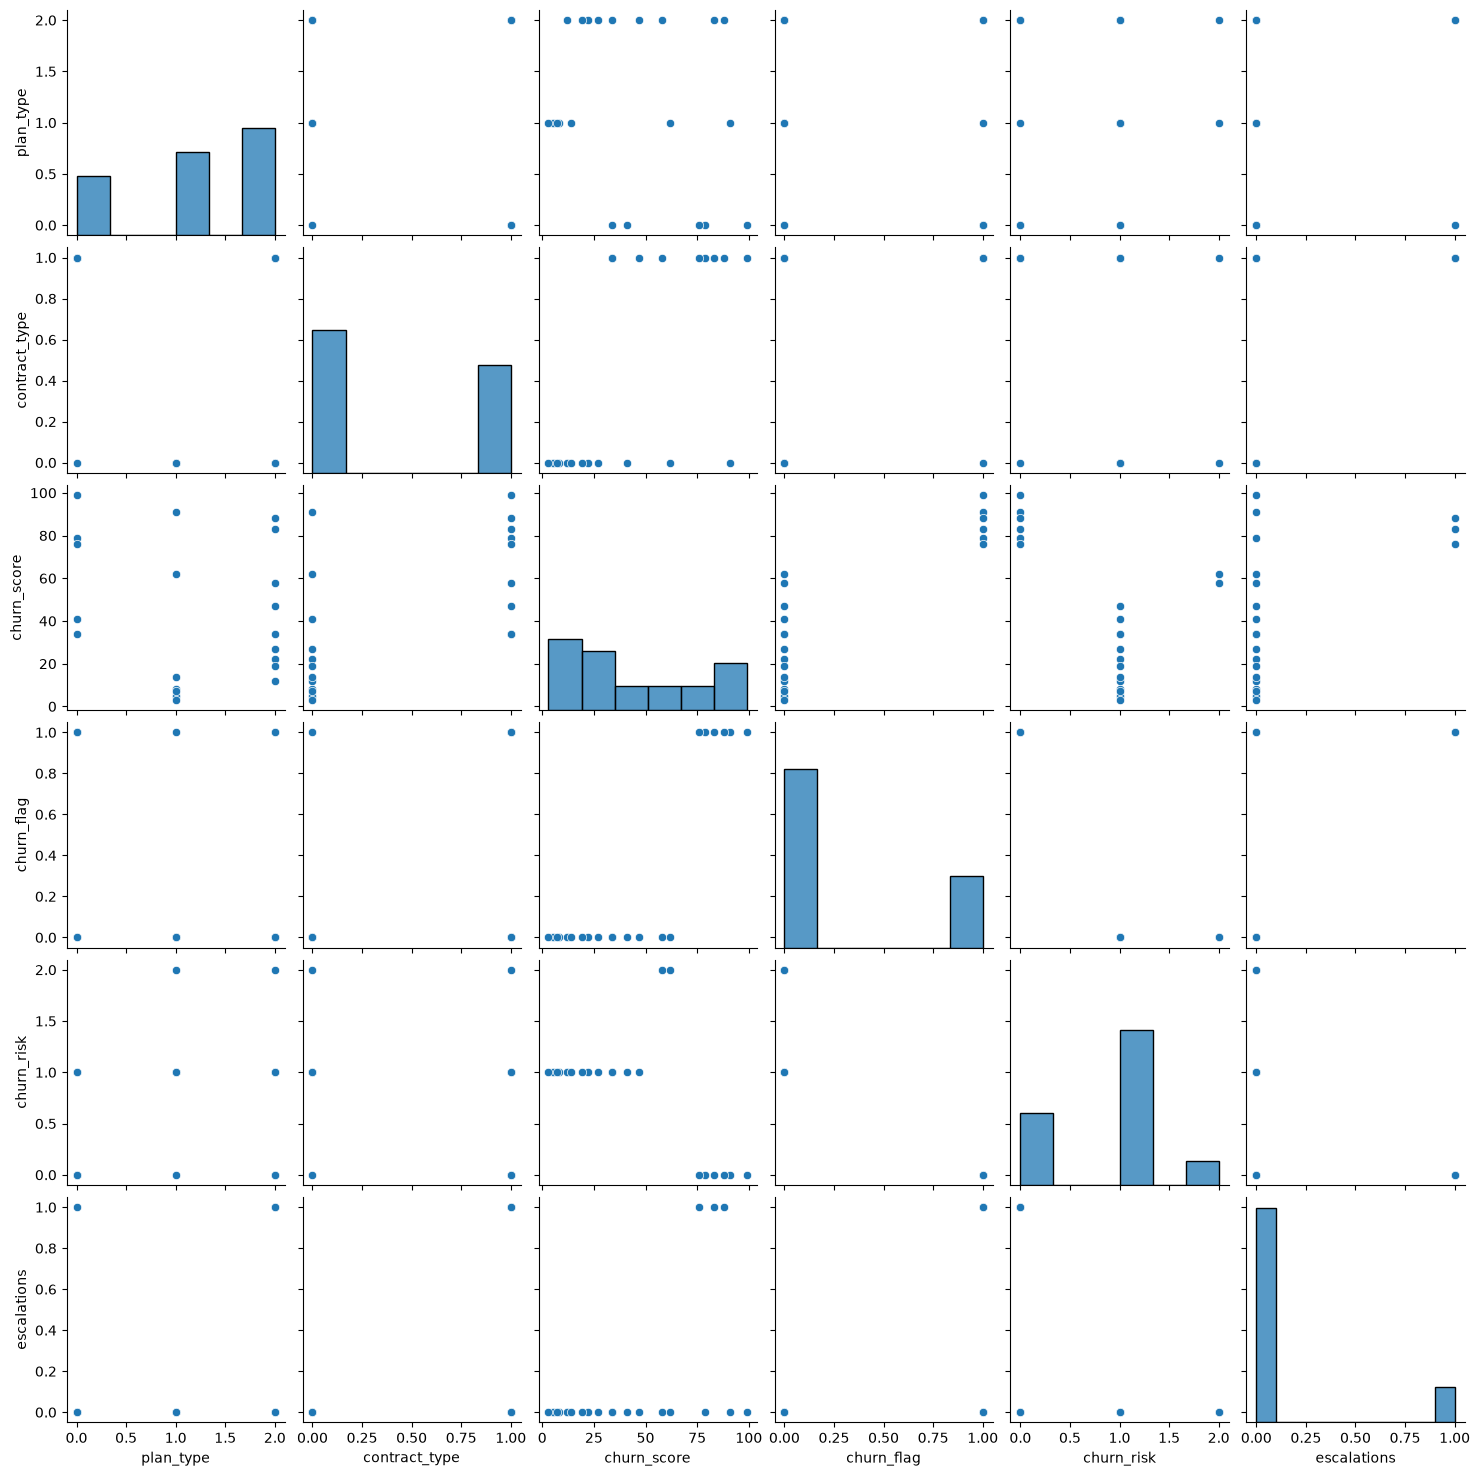

In [166]:
# pairplot

sb.pairplot(df_encoded)

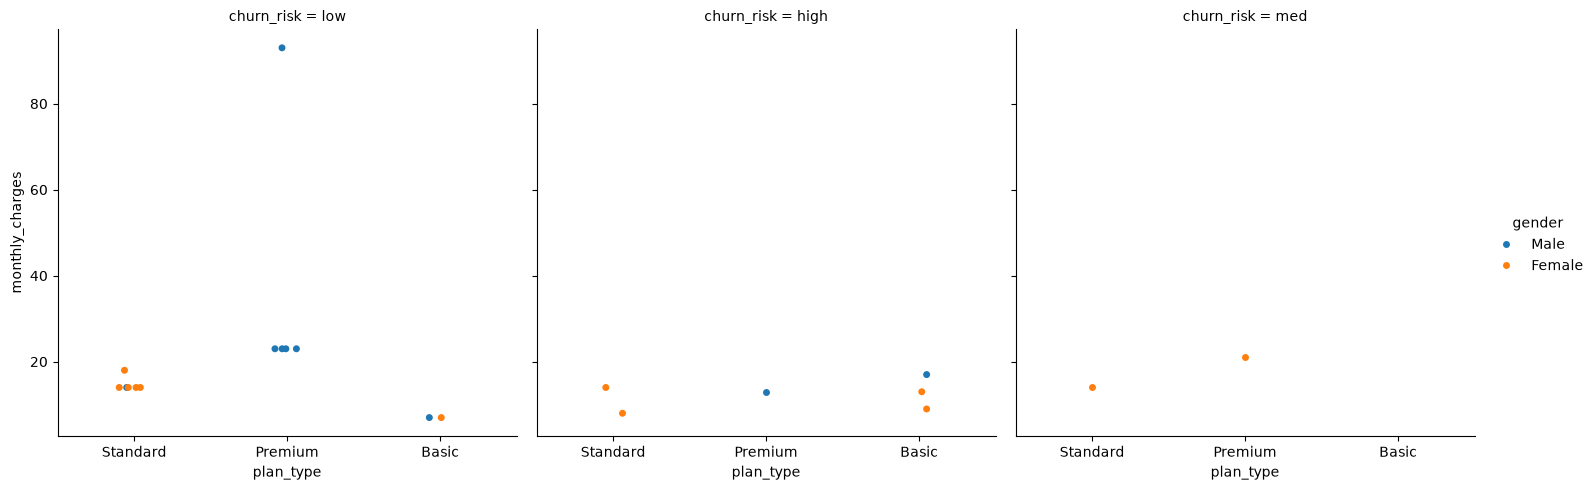

In [167]:
#catplt?facegrid plot -multidim comparison

sb.catplot(data = df_visual,
           x = 'plan_type',
           y = 'monthly_charges',
           hue = 'gender',
           col = 'churn_risk'
          )

In [172]:
# PIVOTTABLE

pd.pivot_table(
    df_visual,
    values= 'churn_flag',
    index= 'plan_type',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [178]:
pd.pivot_table(
    df_visual,
    values= ['churn_flag','monthly_charges', 'customerid'],
    index= 'plan_type',
    aggfunc = {
        'churn_flag' : 'mean',
        'monthly_charges' : 'sum',
        'customerid' : 'nunique'
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [176]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [179]:
conn = sqlite3.connect('database.sqlite')

conn.execute('CREATE TABLE users(first_name TEXT, country TEXT, budget INTEGER)')

conn.commit()